**Loading your dataset from uploaded csv file**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math

# -----------------------------
# 1. Load dataset
# -----------------------------
data = np.loadtxt("dataset.txt")  # first column = feature, second column = continuous label
X = data[:, :-1]

# Convert the continuous label column to discrete classes (0 or 1)
label_threshold = 0.5  # values >= 0.5 become class 1, otherwise class 0
y = (data[:, -1] >= label_threshold).astype(int)

# -----------------------------
# 2. Normalize features (0-1)
# -----------------------------
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

# -----------------------------
# 3. Split into training and test sets (70%-30%) with reproducibility
# -----------------------------
student_id = 112230806
np.random.seed(student_id)
indices = np.arange(len(X))
np.random.shuffle(indices)

train_size = int(0.7 * len(X))
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (261, 1)
Test shape: (112, 1)


K = 1 -> Accuracy = 0.6607
K = 3 -> Accuracy = 0.6875
K = 5 -> Accuracy = 0.7232
K = 7 -> Accuracy = 0.7321


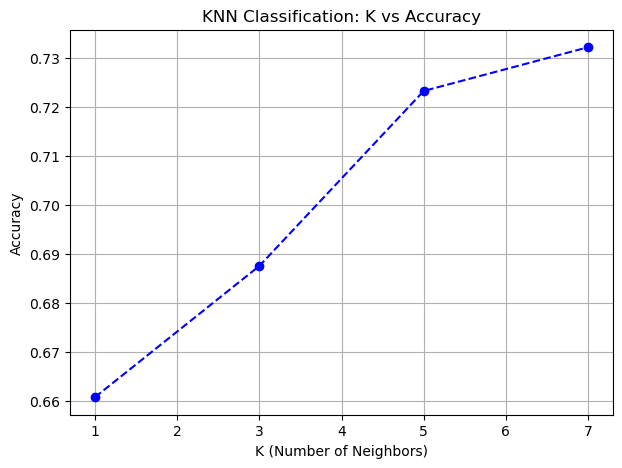

In [7]:
# -----------------------------
# 4. Euclidean distance
# -----------------------------
def euclidean(a, b):
    return math.sqrt(np.sum((a - b) ** 2))

# -----------------------------
# 5. Get K nearest neighbors
# -----------------------------
def get_k_nearest_neighbors(X_train, y_train, test_point, K):
    distances = [(euclidean(test_point, X_train[i]), y_train[i])
                 for i in range(len(X_train))]
    distances.sort(key=lambda x: x[0])
    return distances[:K]

# -----------------------------
# 6. Majority vote
# -----------------------------
def majority_vote(neighbors):
    labels = [label for _, label in neighbors]
    return max(set(labels), key=labels.count)

# -----------------------------
# 7. KNN prediction
# -----------------------------
def knn_predict(X_train, y_train, X_test, K):
    predictions = []
    for test_point in X_test:
        neighbors = get_k_nearest_neighbors(X_train, y_train, test_point, K)
        pred = majority_vote(neighbors)
        predictions.append(pred)
    return np.array(predictions)

# -----------------------------
# 8. Evaluate KNN for different K (manual accuracy)
# -----------------------------
K_values = [1, 3, 5, 7]
accuracies = []

for K in K_values:
    y_pred = knn_predict(X_train, y_train, X_test, K)

    # Manual accuracy calculation
    correct = 0
    for i in range(len(y_test)):
        if y_pred[i] == y_test[i]:
            correct += 1
    accuracy = correct / len(y_test)

    accuracies.append(accuracy)
    print(f"K = {K} -> Accuracy = {accuracy:.4f}")

# -----------------------------
# 9. Plot K vs Accuracy
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(K_values, accuracies, marker='o', linestyle='--', color='blue')
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN Classification: K vs Accuracy")
plt.grid(True)
plt.show()

In [8]:
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt
import math

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load dataset for clustering
# -----------------------------
data = np.loadtxt("dataset.txt")
print("Dataset shape:", data.shape)


Dataset shape: (373, 2)


K = 2 -> Inertia = 20.573932


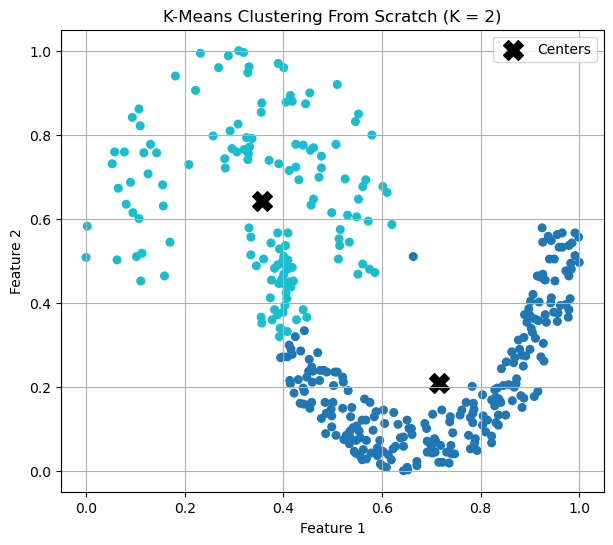

K = 4 -> Inertia = 8.509471


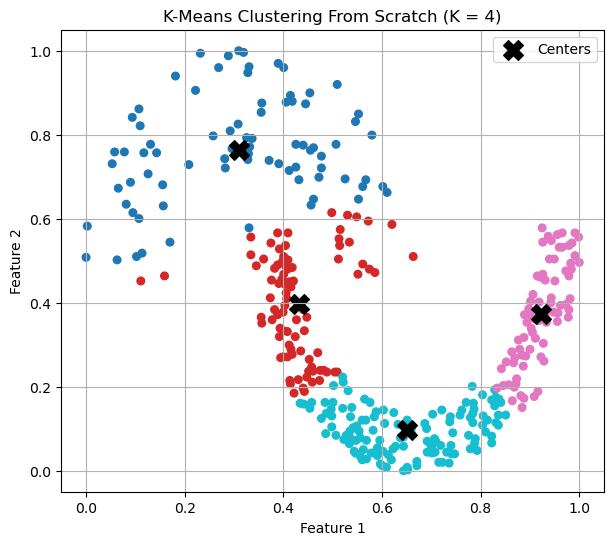

K = 6 -> Inertia = 4.694852


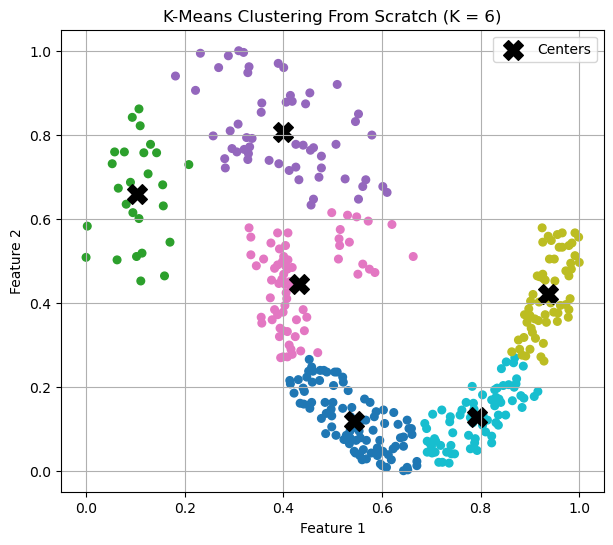

K = 7 -> Inertia = 3.655953


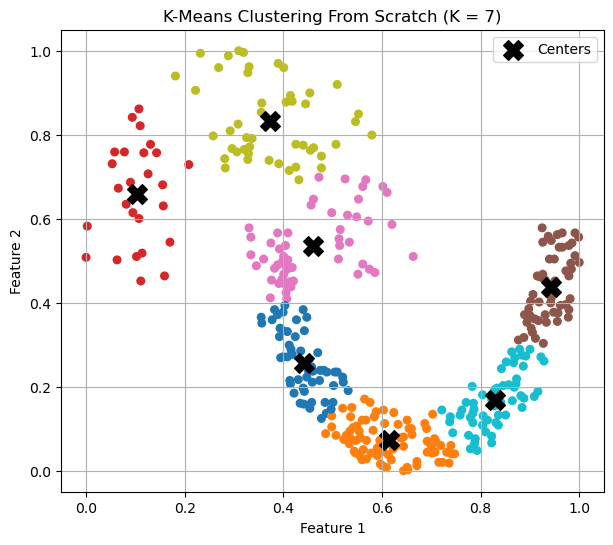

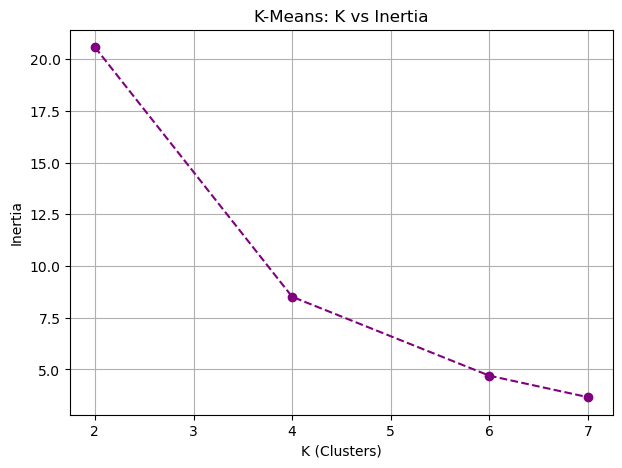

In [10]:
# -----------------------------
# 2. Prepare data (normalization)
# -----------------------------
points = data.copy()
min_vals = points.min(axis=0)
max_vals = points.max(axis=0)
points_norm = (points - min_vals) / (max_vals - min_vals)

student_id = 112230806
np.random.seed(student_id)

# -----------------------------
# 3. K-Means implementation from scratch
# -----------------------------
def run_kmeans(points, K, max_iters=100, tol=1e-4):
    indices = np.random.choice(len(points), K, replace=False)
    centers = points[indices].copy()

    for _ in range(max_iters):
        distances = np.linalg.norm(points[:, None, :] - centers[None, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        new_centers = []
        for k in range(K):
            cluster_points = points[labels == k]
            if len(cluster_points) > 0:
                new_centers.append(cluster_points.mean(axis=0))
            else:
                new_centers.append(centers[k])  # keep old center if cluster empty
        new_centers = np.array(new_centers)

        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        if shift < tol:
            break

    # Compute inertia (sum of squared distances to closest center)
    inertia = 0.0
    for k in range(K):
        cluster_points = points[labels == k]
        if len(cluster_points) > 0:
            inertia += np.sum((cluster_points - centers[k]) ** 2)
    return centers, labels, inertia

# -----------------------------
# 4. Run for K = 2, 4, 6, 7
# -----------------------------
K_values = [2, 4, 6, 7]
inertia_results = []

for K in K_values:
    centers, labels, inertia = run_kmeans(points_norm, K)
    inertia_results.append(inertia)
    print(f"K = {K} -> Inertia = {inertia:.6f}")

    plt.figure(figsize=(7, 6))
    plt.scatter(points_norm[:, 0], points_norm[:, 1], c=labels, cmap='tab10', s=30)
    plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200, c='black', label='Centers')
    plt.title(f"K-Means Clustering From Scratch (K = {K})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()

# -----------------------------
# 5. Plot inertia vs K
# -----------------------------
plt.figure(figsize=(7, 5))
plt.plot(K_values, inertia_results, marker='o', linestyle='--', color='purple')
plt.xlabel('K (Clusters)')
plt.ylabel('Inertia')
plt.title('K-Means: K vs Inertia')
plt.grid(True)
plt.show()